# **A/B тест двух кампаний для одного продукта**

В процессе A/B-тестирования пользователям случайным образом показываются две разные версии одного и того же продукта — например, сайта, приложения или интерфейса. Участники контрольной группы взаимодействуют с исходной (базовой) версией, тогда как участники тестовой группы — с изменённой версией продукта.

Цель тестирования — определить, влияет ли новая версия на поведение пользователей, например, увеличивает ли она количество покупок, кликов или просмотров по сравнению с оригиналом.

**Содержание набора данных:**

```
Campaign Name  : Название кампании
Date           : Дата записи
Spend [USD]    : Сумма, потраченная на кампанию в долларах
Impressions    : Количество показов объявления в ходе кампании
Reach          : Количество уникальных показов рекламы
Website Clicks : Количество кликов на веб-сайте, полученных через рекламу
Searches       : Количество пользователей, выполнивших поиск на сайте
View Content   : Количество пользователей, просмотревших контент и продукты на сайте
Add to Cart    : Количество пользователей, которые добавили продукты в корзину
Purchase       : Количество покупок
```

**Проведено две кампании (два датасета):**

```
control        : Контрольная кампания
test           : Тестовая кампания
```

## **Загрузка и предобработка данных**

In [1]:
# импорт библиотек
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

In [2]:
test = pd.read_csv('/content/test_group.csv', sep=';')
control = pd.read_csv('/content/control_group.csv', sep=';')

In [3]:
df = pd.concat([control, test], ignore_index=True)

In [4]:
df.head()

,Campaign Name,Date,Spend [USD],# of Impressions,Reach,# of Website Clicks,# of Searches,# of View Content,# of Add to Cart,# of Purchase
0,Control Campaign,1.08.2019,2280,82702.0,56930.0,7016.0,2290.0,2159.0,1819.0,618.0
1,Control Campaign,2.08.2019,1757,121040.0,102513.0,8110.0,2033.0,1841.0,1219.0,511.0
2,Control Campaign,3.08.2019,2343,131711.0,110862.0,6508.0,1737.0,1549.0,1134.0,372.0
3,Control Campaign,4.08.2019,1940,72878.0,61235.0,3065.0,1042.0,982.0,1183.0,340.0
4,Control Campaign,5.08.2019,1835,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
# переименуем название столбцов
df = df.rename(columns={'Campaign Name': 'name', 'Date': 'date', 'Spend [USD]': 'spend', '# of Impressions': 'impressions',
                        'Reach': 'reach', '# of Website Clicks': 'clics', '# of Searches': 'searches',
                        '# of View Content': 'view_cont', '# of Add to Cart': 'add_to_card', '# of Purchase': 'purchase'})

df['date'] = pd.to_datetime(df['date'], format='%d.%m.%Y') # преобразование формата данных в дату

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   name         60 non-null     object        
 1   date         60 non-null     datetime64[ns]
 2   spend        60 non-null     int64         
 3   impressions  59 non-null     float64       
 4   reach        59 non-null     float64       
 5   clics        59 non-null     float64       
 6   searches     59 non-null     float64       
 7   view_cont    59 non-null     float64       
 8   add_to_card  59 non-null     float64       
 9   purchase     59 non-null     float64       
dtypes: datetime64[ns](1), float64(7), int64(1), object(1)
memory usage: 4.8+ KB


In [6]:
df.head(8)

,name,date,spend,impressions,reach,clics,searches,view_cont,add_to_card,purchase
0,Control Campaign,2019-08-01,2280,82702.0,56930.0,7016.0,2290.0,2159.0,1819.0,618.0
1,Control Campaign,2019-08-02,1757,121040.0,102513.0,8110.0,2033.0,1841.0,1219.0,511.0
2,Control Campaign,2019-08-03,2343,131711.0,110862.0,6508.0,1737.0,1549.0,1134.0,372.0
3,Control Campaign,2019-08-04,1940,72878.0,61235.0,3065.0,1042.0,982.0,1183.0,340.0
4,Control Campaign,2019-08-05,1835,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,Control Campaign,2019-08-06,3083,109076.0,87998.0,4028.0,1709.0,1249.0,784.0,764.0
6,Control Campaign,2019-08-07,2544,142123.0,127852.0,2640.0,1388.0,1106.0,1166.0,499.0
7,Control Campaign,2019-08-08,1900,90939.0,65217.0,7260.0,3047.0,2746.0,930.0,462.0


В данных присутствуют пропущенные значения в одной строке: практически все показатели отсутствуют за 5 августа 2019 года в контрольной группе. Поскольку данные представлены по дням и один пропущенный день может исказить анализ, его не следует опускать. Значение `spend` за 5 августа близко к предыдущему дню, поэтому все пропущенные значения мы заполним данными за 4 августа.

In [7]:
# заменим промущенные значения для 5 августа данными из 4 августа
idx = df[df['date'] == '2019-08-05'].index[0]

# значения предыдущей строки (4 августа)
prev_day = df.loc[idx - 1]

# Заменим пропуски значениями из предыдущего дня только в числовых колонках
for col in df.columns:
    if pd.isnull(df.at[idx, col]) and pd.api.types.is_numeric_dtype(df[col]):
        df.at[idx, col] = prev_day[col]

## **Анализ данных**

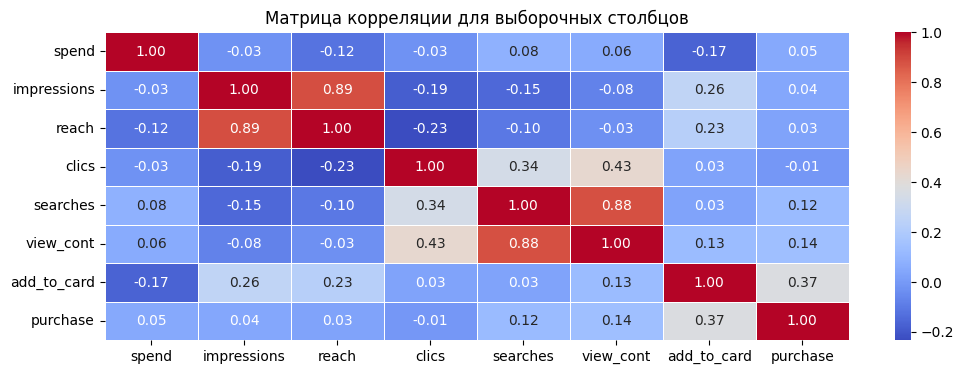

In [8]:
# Рассчитаем матрицу корреляций
metric_columns = ['spend', 'impressions', 'reach', 'clics', 'searches',
                  'view_cont', 'add_to_card', 'purchase']

corr = df[metric_columns].corr(method='spearman')

# Визуализируем матрицу корреляции
plt.figure(figsize=(12, 4))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Матрица корреляции для выборочных столбцов")
plt.show()

В данных есть сорреляции. При необходимотьси строить модели стоит обратить на это внимание, чтобы избежать мультиколлениарности.

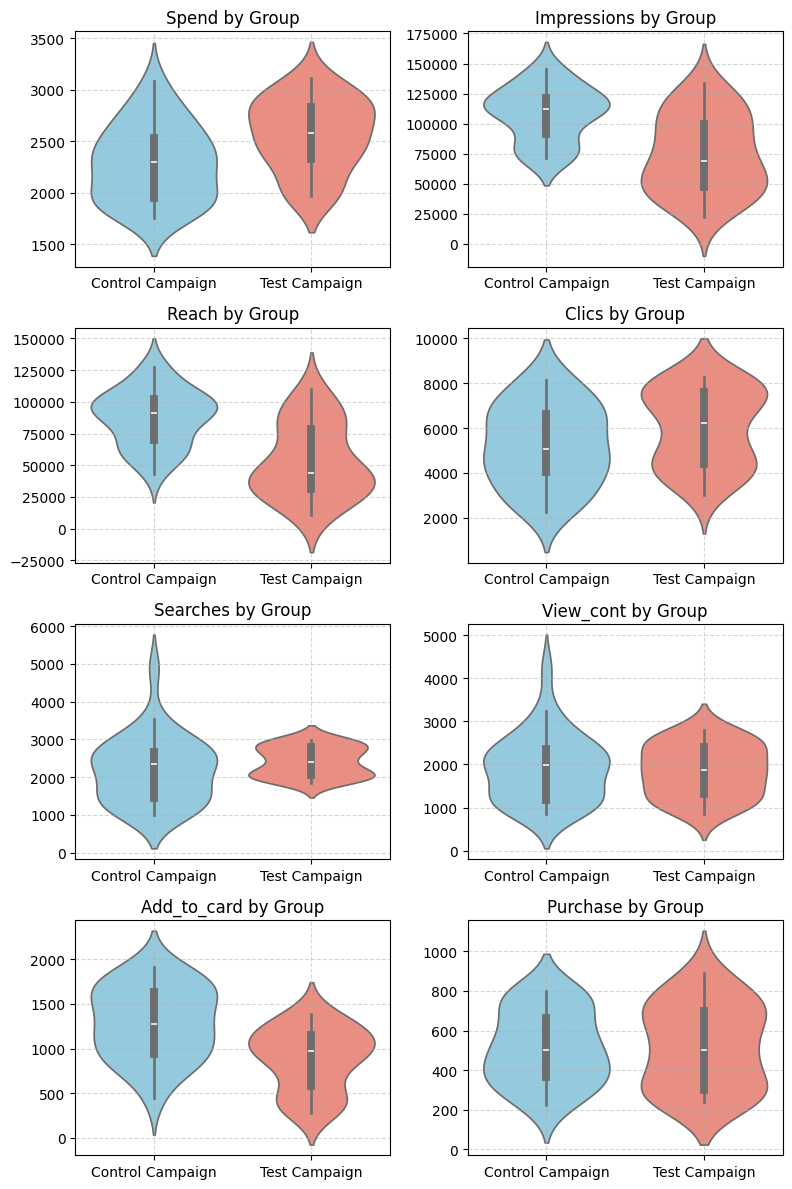

In [9]:
# Построение графиков боксплот для каждого показателя
n_rows = 4
n_cols = 2

fig, axes = plt.subplots(n_rows, n_cols, figsize=(8, 12))
axes = axes.flatten()

palette = {'Control Campaign': 'skyblue', 'Test Campaign': 'salmon'}

for i, col in enumerate(metric_columns):
    sns.violinplot(x='name', y=col, data=df, hue='name', palette=palette, ax=axes[i])
    axes[i].set_title(f'{col.capitalize()} by Group')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')
    axes[i].grid(True, linestyle='--', alpha=0.5)
    if axes[i].get_legend() is not None:
        axes[i].get_legend().remove()

plt.tight_layout()
plt.show()

Из графиков можно сделать вывод о том, что кампании различаются интенсивностью показов уникальной рекламы

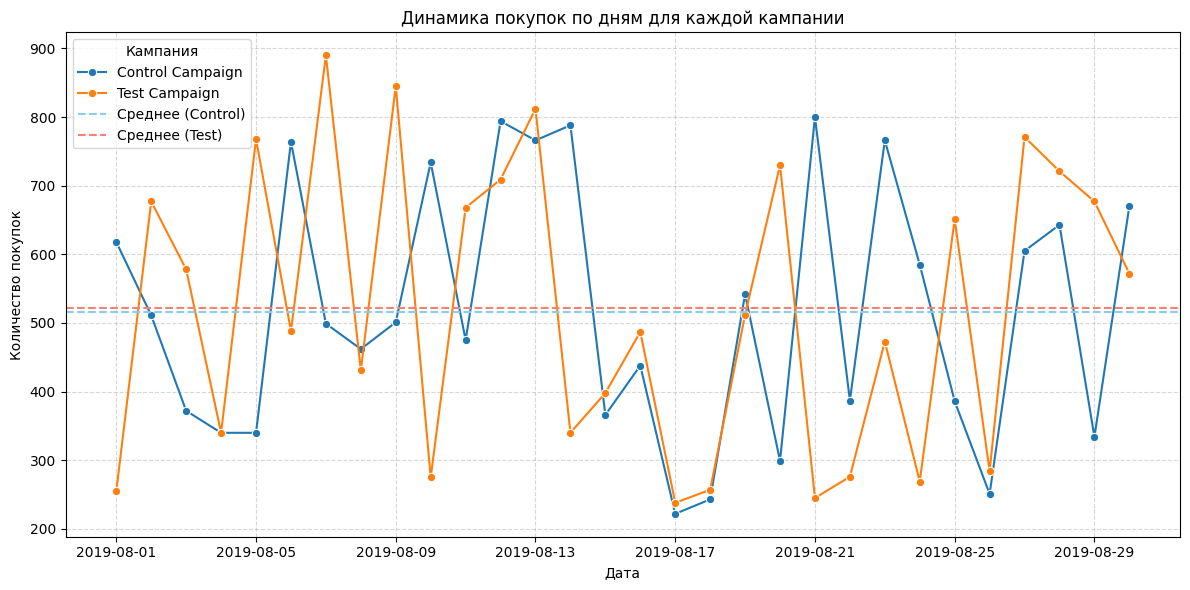

In [10]:
mean_control = df[df['name'] == 'Control Campaign']['purchase'].mean()
mean_test = df[df['name'] == 'Test Campaign']['purchase'].mean()

# Строим график
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='date', y='purchase', hue='name', marker='o')

plt.axhline(mean_control, color='skyblue', linestyle='--', linewidth=1.5, label='Среднее (Control)')
plt.axhline(mean_test, color='salmon', linestyle='--', linewidth=1.5, label='Среднее (Test)')

plt.title('Динамика покупок по дням для каждой кампании')
plt.xlabel('Дата')
plt.ylabel('Количество покупок')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Кампания')
plt.tight_layout()
plt.show()

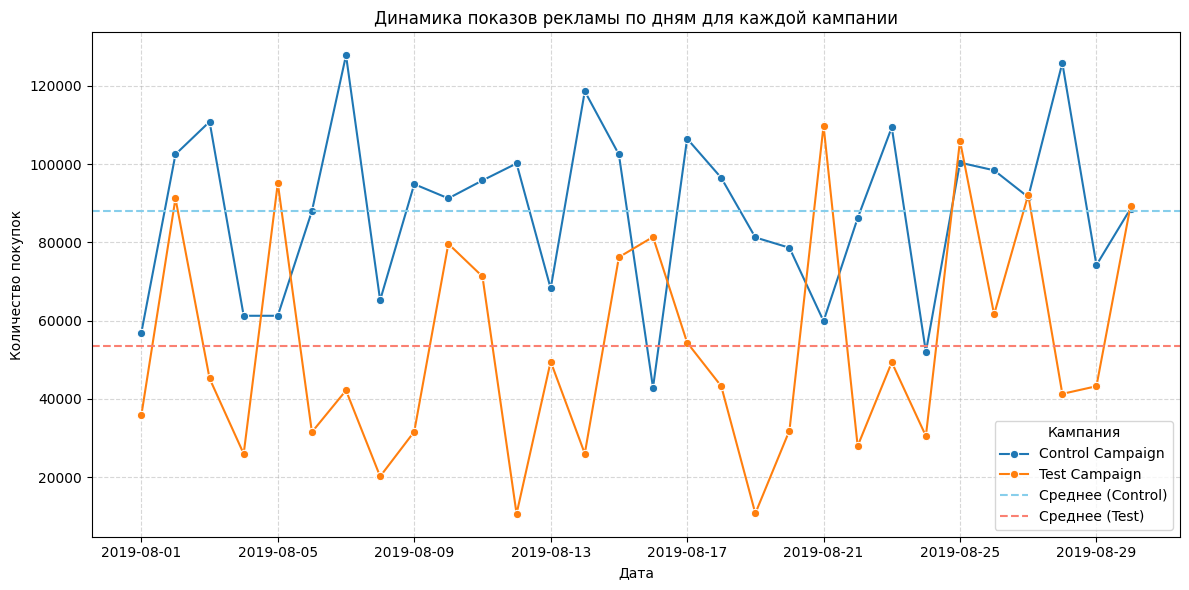

In [11]:
mean_control = df[df['name'] == 'Control Campaign']['reach'].mean()
mean_test = df[df['name'] == 'Test Campaign']['reach'].mean()

# Строим график
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='date', y='reach', hue='name', marker='o')

plt.axhline(mean_control, color='skyblue', linestyle='--', linewidth=1.5, label='Среднее (Control)')
plt.axhline(mean_test, color='salmon', linestyle='--', linewidth=1.5, label='Среднее (Test)')

plt.title('Динамика показов рекламы по дням для каждой кампании')
plt.xlabel('Дата')
plt.ylabel('Количество покупок')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Кампания')
plt.tight_layout()
plt.show()

Судя по графикам можно сделать вывод о том, что данные распределены не нормально.

Количество показов для тестовой группы увеличилось, тогда как количество показов уникальной рекламы уменьшилось, а затраты на тестовую кампанию увеличились.

## **Тестирование**

Для анализа определим метрики:
```
Метрика                       Расчёт                                Интерпритация
                      
Purchase                      purchase                              Абсолютное количество покупок (конверсий)
Spend                         spend                                 Общий расход на рекламную кампанию (в USD)
Impressions                   impressions                           Общее количество показов рекламы
Reach                         reach                                 Количество уникальных пользователей, увидевших рекламу
Website Clicks                clics                                 Количество переходов на сайт (клики по рекламе)
Searches                      searches                              Количество поисковых запросов на сайте
View Content                  view_cont                             Количество просмотров товаров/контента
Add to Cart                   add_to_card                           Количество добавлений товаров в корзину
CTR (Click-through rate)      clicks / impressions                  Процент кликов от общего числа показов
CTR_unique                    clicks / reach                        Процент кликов от уникального охвата
Search Rate                   searches / reach                      Процент пользователей, выполнивших поиск после показа рекламы
VCR (View Content Rate)       view_content / reach                  Процент пользователей, просмотревших контент
Add to Cart Rate              add_to_cart / view_content            Конверсия из просмотра в корзину
Purchase Rate                 purchase / website_clicks             Конверсия из кликов в покупки
CPC                           spend / clics                         Стоимость одного клика
CPM (Cost Per Mille)          Spend / (Impressions / 1000)          Стоимость 1000 показов.
CPV (Cost Per View)           Spend / View Content                  Стоимость одного просмотра контента.
CPA (Cost Per Purchase)       Spend / Purchase                      Стоимость одной покупки.
CPATC (Cost Per Add to Cart)  Spend / Add to Cart                   Стоимость одного добавления в корзину.
Bounce Rate                   (Website Clicks - View Content) / Website Clicks	 Процент пользователей, ушедших без просмотра контента.
Cart Abandonment Rate         (Add to Cart - Purchase) / Add to Cart           Процент брошенных корзин.

```

In [16]:
# Определение метрик

df['ctr'] = df['clics'] / df['impressions']
df['ctr_unique'] = df['clics'] / df['reach']
df['search_rate'] = df['searches'] / df['reach']
df['vcr'] = df['view_cont'] / df['impressions']
df['vcr_unique'] = df['view_cont'] / df['reach']
df['cart_rate'] = df['add_to_card'] / df['view_cont']
df['purchase_rate'] = df['purchase'] / df['clics']
df['cpc'] = df['spend'] / df['clics']
df['cpm'] = df['spend'] / (df['impressions']/1000)
df['cpv'] = df['spend'] / df['view_cont']
df['cpa'] = df['spend'] / df['purchase']
df['cpatc'] = df['spend'] / df['add_to_card']
df['br'] = (df['clics'] - df['view_cont']) / df['clics']
df['car'] = (df['add_to_card'] - df['purchase']) / df['add_to_card']
metrics = ['spend', 'impressions', 'reach', 'clics', 'searches','view_cont', 'add_to_card', 'purchase',
           'ctr', 'cpm', 'cpv', 'cpa', 'cpatc', 'br', 'ctr_unique', 'search_rate', 'vcr', 'cpc', 'car',
           'vcr_unique', 'cart_rate', 'purchase_rate']

In [17]:
results = []

for metric in metrics:
    control = df[df['name'] == 'Control Campaign'][metric].dropna()
    test = df[df['name'] == 'Test Campaign'][metric].dropna()

    stat, pval = mannwhitneyu(control, test, alternative='two-sided')

    mean_control = control.mean()
    mean_test = test.mean()
    rel_change = ((mean_test - mean_control) / mean_control) * 100

    results.append({
        'Metric': metric,
        'p-value': round(pval, 4),
        'Control Mean': round(mean_control, 2),
        'Test Mean': round(mean_test, 2),
        'Relative Change (%)': round(rel_change, 2),
        'Significant': 'Yes' if pval < 0.05 else 'No'
    })

results_df = pd.DataFrame(results)
results_df

,Metric,p-value,Control Mean,Test Mean,Relative Change (%),Significant
0,spend,0.0044,2288.43,2563.07,12.00,Yes
1,impressions,0.0001,108337.03,74584.80,-31.15,Yes
2,reach,0.0000,87924.60,53491.57,-39.16,Yes
3,clics,0.0993,5245.60,6032.33,15.00,No
4,searches,0.1260,2182.00,2418.97,10.86,No
5,view_cont,0.9234,1911.73,1858.00,-2.81,No
6,add_to_card,0.0005,1296.10,881.53,-31.99,Yes
7,purchase,0.9823,516.70,521.23,0.88,No
8,ctr,0.0002,0.05,0.10,102.17,Yes
9,cpm,0.0000,21.83,42.68,95.51,Yes


Метрики, где изменения значимы:
```
Metric         Изменение   Интерпретация

spend          +12%        Тестовая кампания стоила дороже. Значимое увеличение бюджета.
impressions    -31%        Показы в тестовой кампании упали.
reach          -39%        Охват значительно ниже в тесте.
add_to_card    -32%        Пользователи реже добавляли в корзину — тревожный сигнал.
ctr_unique     +172%       Резко вырос Click-Through Rate — реклама стала заметно более кликабельной.
ctr            +102%       Вырос Click-Through Rate от показов видимо за счет рекламы.
cpm            +95%        Стоимость 1000 показов значительно выше на тесте
cpatc          +79%        Стоимоть одного добавления в корзину возрасла
search_rate    +143%       Больше пользователей стали искать товары после клика.
vcr_unique     +121%       Больше пользователей смотрят контент — вовлеченность выше.
vcr            +69%        Больше пользователей смотрят контент — вовлеченность выше скорее за счет рекламы.
cart_rate      -35%        Несмотря на вышеописанное, в корзину добавляют реже — проблема конверсии.
car            -30%        Однако, процент брошеных корзин уменьшился.
```

Метрики без значимых изменений:
```
Metric         Интерпретация

clics          Хотя кликов стало больше, статистически это незначимо.
searches       Разница в поисках незначительна.
view_cont      Просмотры контента примерно на том же уровне.
purchase       Количество покупок почти не изменилось.
purchase_rate  Конверсия в покупку снизилась на 19%, но это не статистически значимо.
cpc            Цена за клик критически не изменилась
cpv            Цена одного просмотра не изменилась
cpa            Стоимотсть одной покупки не изменилась
br             Процент пользователей, ушедших без просмотра контента, не изменилось
```

# **Выводы**

Наблюдается рост вовлеченности. Вовлеченность в рекламу и взаимодействие с сайтом (CTR, search_rate, vcr) в тесте выросли, что говорит о более интересной рекламе. Также уменьшилось количество брошенных корзин.

Но реклама стала менее эффективной по стоиомсти.

Наблюдается проблема в финальной конверсии (add_to_cart и cart_rate значительно упали).

Покупки не увеличились, несмотря на рост вовлеченности. Это может означать, что тест не дал реальной бизнес-выгоды, или что нужно улучшать конверсию в покупки после клика.

С учетом того, что количество брошенных корзин уменьшилось, а вовлеченность аудитории увеличилась, но снизилось количество покупок, стоит обратить внимание на корректность работы кнопки "корзина" и проверить привлекаемый контингент, возможно изменилась аудитория или изменился описание, состав, качество и стоимость товаров.